In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

palette = {'wt': 'blue','heterozygous':'orange','mutated':'red'}

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')


In [3]:
variant = 'JAK2 c.1849G>T'

In [4]:
adata.obs['genotype'] = adata.obsm['genotypes'][[variant + '_wt', variant + '_mutated', variant + '_heterozygous']].idxmax(axis=1, skipna=True)
adata.obs['genotype'] = adata.obs['genotype'].str.replace(variant + '_', '', regex=False)

min_1_condition = (adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 0)
min_2_condition = (adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 1)


/tmp/ipykernel_781158/981935251.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  adata.obs['genotype'] = adata.obsm['genotypes'][[variant + '_wt', variant + '_mutated', variant + '_heterozygous']].idxmax(axis=1, skipna=True)


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


12614 cells with at least 1 high confidence count in BC010_1


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


3769 cells with at least 2 high confidence counts in BC010_1


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


...

1168 cells with at least 2 high confidence counts in BC001_4-plex


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


22515 cells with at least 1 high confidence count in BC003_4-plex


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


9314 cells with at least 2 high confidence counts in BC003_4-plex


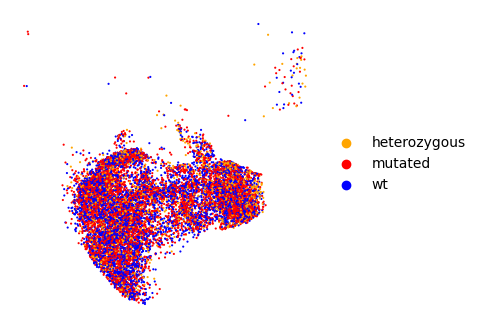

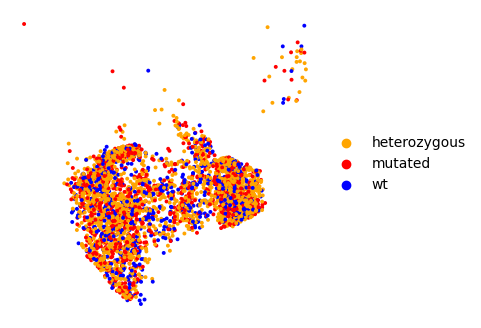

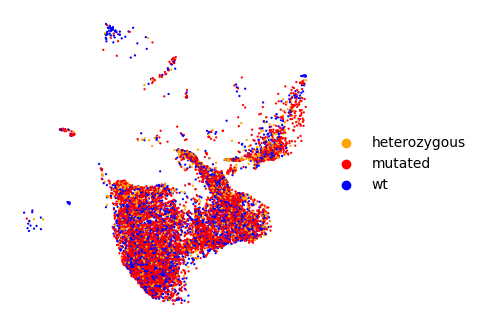

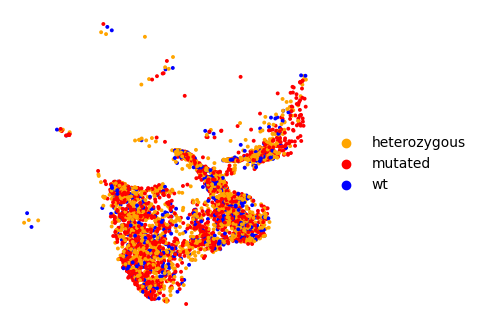

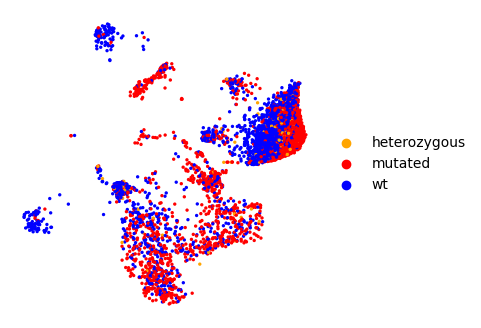

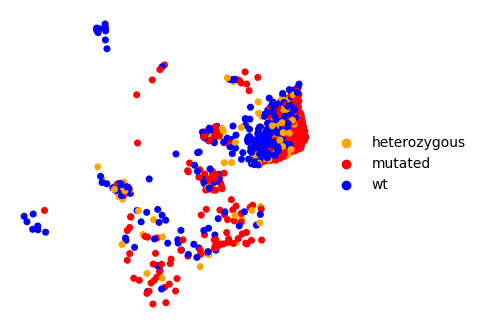

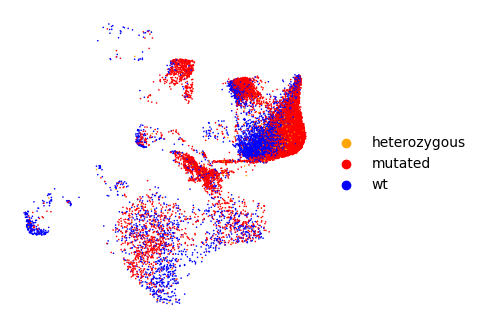

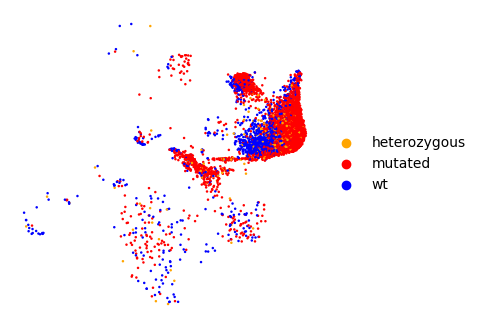

In [5]:
samples = ['BC010_1', 'BC006_1', 'BC001_4-plex', 'BC003_4-plex']
for sample in samples:
    fig,ax = plt.subplots(figsize=(4,4))
    sc.pl.umap(adata[(adata.obs['sample'] == sample) & min_1_condition], color='genotype', palette=palette, ax=ax, show=False, frameon=False, title = '')
    print(len(adata[(adata.obs['sample'] == sample) & min_1_condition]), 'cells with at least 1 high confidence count in', sample)
    plt.savefig(f'../plots/UMAP_{sample}_min1.pdf', bbox_inches='tight')
    fig,ax = plt.subplots(figsize=(4,4))
    sc.pl.umap(adata[(adata.obs['sample'] == sample) & min_2_condition], color='genotype', palette=palette, ax=ax, show=False, frameon=False, title = '')
    print(len(adata[(adata.obs['sample'] == sample) & min_2_condition]), 'cells with at least 2 high confidence counts in', sample)

    # Get current axes and rasterize scatter points
    ax = plt.gca()
    for coll in ax.collections:
        coll.set_rasterized(True)

    plt.savefig(f'../plots/UMAP_{sample}_min2.pdf', bbox_inches='tight')